In [1]:
import os
os.environ["JAX_PLATFORM_NAME"] = "gpu"

import jax
import jax.numpy as jnp
import flax.linen as nn
import netket as nk
import optax
import numpy as np
import matplotlib.pyplot as plt
import json
from tqdm import tqdm

print(jax.devices())

from src_renyi import (
    ARNN_Z2, RBM_Z2,
    FreeRenyiEnergyObservable,
    free_energy_minimize_SR_SGD,
    free_energy_minimize_scipy,
)

[CudaDevice(id=0)]


In [2]:
# Hilbert space
from netket.hilbert import Spin
N = 20
N_ancilla = 20

# System: N 1/2
# Ancilla: N_ancilla  1/2
# Total space = spin ⊗ ancilla
hi_system = nk.hilbert.Spin(s=1/2, N=N)
hi_ancilla = nk.hilbert.Spin(s=1/2, N=N_ancilla)
hi_extended = nk.hilbert.Spin(s=1/2, N=N+N_ancilla)

partition = list(range(N)) 

$\mathcal{H_0}=Γ \sum_{i}\sigma_i^{(x)}+V\sum_{i}\sigma_i^{(z)}\sigma_{i+1}^{z} \qquad \mathcal{H_R}=\mathbb{I}_R$

$\mathcal{H}=\mathcal{H_0}\otimes\mathbb{I}_R$

In [3]:
# Pauli matrices import, Hamiltonian  H = H_0 ⊗ I_R
from netket.operator.spin import sigmax, sigmaz
Gamma = -1.5  
V = -1
H_system=0
H_extended = 0

for i in range(N):
    H_system += Gamma * sigmax(hi_system, i)
    H_system += V * sigmaz(hi_system, i) @ sigmaz(hi_system, (i + 1) % N)

for i in range(N):
    H_extended += Gamma * sigmax(hi_extended, i)
    H_extended += V * sigmaz(hi_extended, i) @ sigmaz(hi_extended, (i + 1) % N)

$F_R=\langle H \rangle -TS_2$

Necesitamos una función que calcule $S_2$ y su gradiente. Utilizaremos:

$S_2=-\log(Tr(\rho_A^2))=-\log\left\langle\frac{\psi(r,\eta')\psi(r',\eta)}{\psi(r,\eta)\psi(r',\eta')}\right\rangle$

Quantum Neural Network training at a given temperature

In [ ]:
partition = list(range(N))
sampler = nk.sampler.ARDirectSampler(hi_extended)

arnn = nk.models.ARNNDense(hilbert=hi_extended, layers=1, features=16, activation=jax.nn.gelu)
model = ARNN_Z2(worker=arnn, trivial_Z2=True)
vstate = nk.vqs.MCState(sampler, model, n_samples=40960*2)
T = 30

n_steps = 300
lr = optax.warmup_cosine_decay_schedule(0.005, 0.005, 50, n_steps, 0.0001)
diag_shift = optax.linear_schedule(1e-1, 1e-4, n_steps)

_,f_best,E_best,S_best = free_energy_minimize_SR_SGD(vstate, T, partition, H_extended, n_steps, learning_rate=lr,
                                                      diag_shift=diag_shift, freq=20, timing=True, n_samples_sr=4096)
print(f"Best solution: S₂={S_best:.6f}, E={E_best:.6f}, F={f_best:.6f}")

Step    0 | F=-149.628543 | t=8.091s
Step   20 | F=-226.152593 | t=0.857s
Step   40 | F=-228.636948 | t=0.767s


Training at different temperatures

Temperaturas:   0%|          | 0/20 [00:00<?, ?it/s]


=== Temperatura T = 0.000 ===
Step    0 | F=-29.919102
Step   50 | F=-33.437440
Step  100 | F=-33.437082
Step  150 | F=-33.437266
Step  200 | F=-33.436978
Step  250 | F=-33.437902


Temperaturas:   5%|▌         | 1/20 [02:30<47:40, 150.55s/it]

  Mejor resultado: E=-33.4373, S₂=0.0000, F=-33.4373

=== Temperatura T = 0.789 ===
Step    0 | F=-29.737449
Step   50 | F=-33.524823
Step  100 | F=-33.547216
Step  150 | F=-33.573175
Step  200 | F=-33.569192
Step  250 | F=-33.602114


Temperaturas:  10%|█         | 2/20 [05:01<45:11, 150.64s/it]

...

  Mejor resultado: E=-2.4651, S₂=8.8274, F=-120.9387

=== Temperatura T = 14.211 ===
Step    0 | F=-30.338090
Step   50 | F=-72.944951
Step  100 | F=-77.736135
Step  150 | F=-84.577398
Step  200 | F=-95.074149
Step  250 | F=-112.744967


Temperaturas:  95%|█████████▌| 19/20 [46:46<02:25, 145.09s/it]

  Mejor resultado: E=-3.2650, S₂=8.8286, F=-128.7237

=== Temperatura T = 15.000 ===
Step    0 | F=-30.541481
Step   50 | F=-56.213365
Step  100 | F=-73.864279
Step  150 | F=-83.667179
Step  200 | F=-103.576704
Step  250 | F=-114.686265


Temperaturas: 100%|██████████| 20/20 [49:19<00:00, 147.98s/it]

  Mejor resultado: E=-2.9731, S₂=8.6731, F=-133.0693


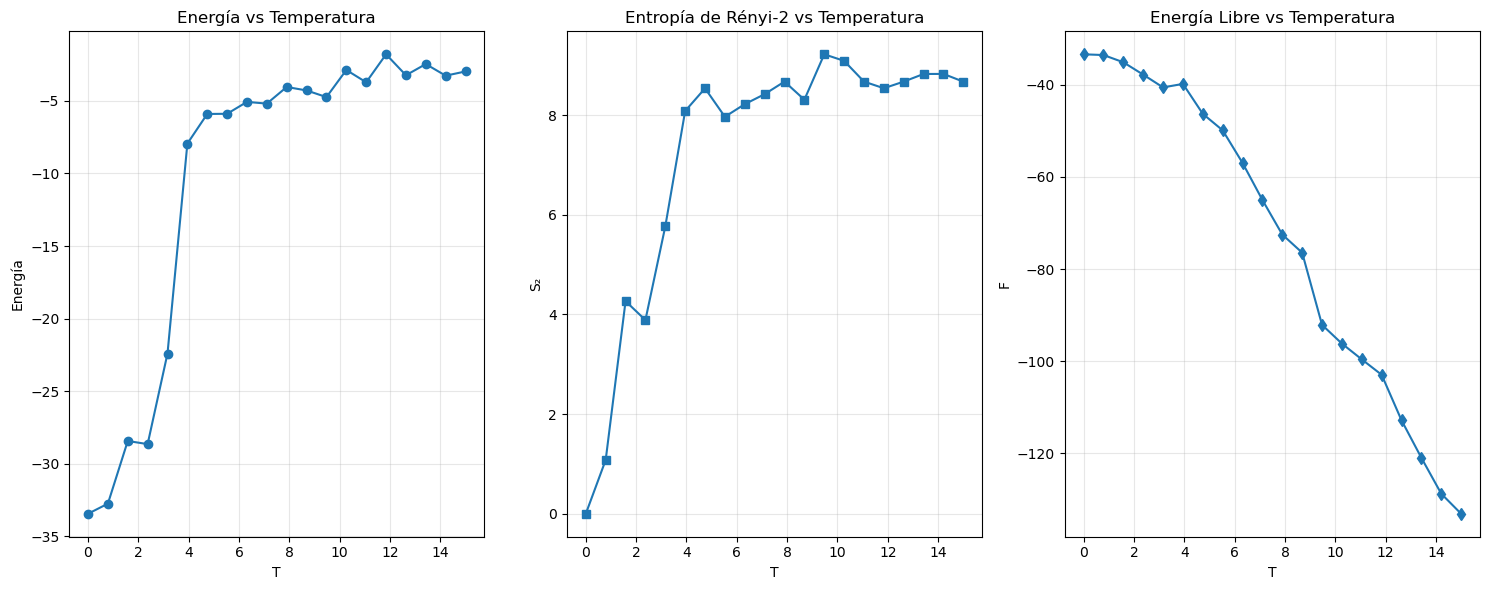

In [17]:
partition = list(range(N))
sampler = nk.sampler.ARDirectSampler(hi_extended)
model = nk.models.ARNNDense(hilbert=hi_extended, layers=1, features=16, activation=jax.nn.gelu)
vstate = nk.vqs.MCState(sampler, model, n_samples=40960, chunk_size=None)

T_array = np.linspace(0, 15, 20)
n_steps = 300

energy_results = []
entropy_results = []
free_energy_results = []
all_histories = []
best_params = None

for T_idx, T in enumerate(tqdm(T_array, desc="Temperaturas")):
    print(f"\n=== Temperatura T = {T:.3f} ===")

    vstate.init_parameters()
    # if best_params is not None:
    #     vstate.parameters = best_params

    free_energy_history, best_F, best_energy, best_entropy = free_energy_minimize_SR_SGD(
        vstate=vstate,
        T=T,
        partition=partition,
        Hamiltonian=H_extended,
        n_steps=n_steps,
        verbose=True,
        plot=False,
        learning_rate=optax.warmup_cosine_decay_schedule(0.05, 0.05, 80, n_steps, 0.001),
        diag_shift=optax.linear_schedule(1e-1, 1e-4, n_steps),
        n_samples_sr=4096
    )
    best_params = vstate.parameters

    energy_results.append(best_energy)
    entropy_results.append(best_entropy)
    free_energy_results.append(best_F)

    all_histories.append({
        "T": T,
        "free_energy": free_energy_history,
    })

    print(f"  Mejor resultado: E={best_energy:.4f}, S₂={best_entropy:.4f}, F={best_F:.4f}")

# Visualización
plt.figure(figsize=(15, 6))

plt.subplot(1, 3, 1)
plt.plot(T_array, energy_results, 'o-')
plt.xlabel('T'); plt.ylabel('Energía'); plt.title('Energía vs Temperatura'); plt.grid(True, alpha=0.3)

plt.subplot(1, 3, 2)
plt.plot(T_array, entropy_results, 's-')
plt.xlabel('T'); plt.ylabel('S₂'); plt.title('Entropía de Rényi-2 vs Temperatura'); plt.grid(True, alpha=0.3)

plt.subplot(1, 3, 3)
plt.plot(T_array, free_energy_results, 'd-')
plt.xlabel('T'); plt.ylabel('F'); plt.title('Energía Libre vs Temperatura'); plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("output.png", dpi=200, bbox_inches="tight")
plt.show()

In [19]:
os.makedirs("../data", exist_ok=True)

data = {
    "T": [float(T) for T in T_array],
    "energy": [float(x) for x in energy_results],
    "entropy": [float(x) for x in entropy_results],
    "free_energy": [float(x) for x in free_energy_results],
}

with open(f"../data/results_N{N}_vs_T.txt", "w") as f:
    json.dump(data, f, indent=2)


Scipy minimization

In [ ]:
model = RBM_Z2(alpha=1, trivial_Z2=True)
vstate = nk.vqs.FullSumState(hilbert=hi_extended, model=model)
vstate.init_parameters

result = free_energy_minimize_scipy(
    vstate,
    T=0.9,
    partition=partition,
    Hamiltonian=H_extended,
    method="BFGS",
    options={"maxiter": 10000},
    verbose=False
)

print(result["result"].success)
print(f"Best F={result['best_F']:.6f}, E={result['best_energy']:.6f}, S₂={result['best_entropy']:.6f}")

In [ ]:
T_array_scipy = np.linspace(0, 10, 60)
model = RBM_Z2(alpha=1, trivial_Z2=True)

energy_results_scipy = []
entropy_results_scipy = []  
free_energy_results_scipy = []

for T in T_array_scipy:
    vstate = nk.vqs.FullSumState(hilbert=hi_extended, model=model) 
    result = free_energy_minimize_scipy(
        vstate,
        T=T,
        partition=partition,
        Hamiltonian=H_extended,
        method="L-BFGS-B",
        options={"maxiter": 50000},
        verbose=False
    )
    energy_results_scipy.append(result["best_energy"])
    entropy_results_scipy.append(result["best_entropy"])
    free_energy_results_scipy.append(result["best_F"])
    print(f"T={T:.3f} -- F={result['best_F']:.6f}, E={result['best_energy']:.6f}, S₂={result['best_entropy']:.6f}, {result['result'].success}")

plt.plot(T_array_scipy, free_energy_results_scipy, label=r"$F$")
plt.plot(T_array_scipy, energy_results_scipy, label=r"$\langle H\rangle$")
plt.plot(T_array_scipy, entropy_results_scipy, label=r"$S_2$")
plt.legend()
plt.show()

In [ ]:
#Comparar con scipy
fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(15, 5))

ax1.scatter(T_array, free_energy_results, color="Blue", s=10, alpha=0.5, label="RBM")
ax1.plot(T_array_scipy, free_energy_results_scipy, color="Blue", label="Scipy")
ax1.set_xlabel("T")
ax1.set_ylabel("$F$")
ax1.set_title("Free energy")
ax1.legend()
ax1.grid(True, alpha=0.3)

ax2.scatter(T_array, energy_results, color="Orange", s=10, alpha=0.5, label="RBM")
ax2.plot(T_array_scipy, energy_results_scipy, color="Orange", label="Scipy")
ax2.set_xlabel("T")
ax2.set_ylabel("$<H>$")
ax2.set_title("$Energy$")
ax2.legend()
ax2.grid(True, alpha=0.3)

ax3.scatter(T_array, entropy_results, color="Green", s=10, alpha=0.5, label="RBM")
ax3.plot(T_array_scipy, entropy_results_scipy, color="Green", label="Scipy")
ax3.set_xlabel("T")
ax3.set_ylabel("$S_2$")
ax3.set_title("Entanglement entropy")
ax3.legend()
ax3.grid(True, alpha=0.3)

plt.tight_layout()

plt.show()